# EDA: ALI=F (Aluminum Futures)
### Exploratory Data Analysis - Ringkas & To-the-Point

**Tujuan:** Memahami kualitas dan karakteristik data untuk Machine Learning

**Dataset:** ALI=F (Futures Aluminium) dari Yahoo Finance

## 1️. Loading & Inspection

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download data
SYMBOL = "ALI=F"
df = yf.download(
    SYMBOL,
    start="2000-01-01",
    interval="1d",
    auto_adjust=False,
    repair=True,
    keepna=True,
    progress=False
)

# Flatten MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] for c in df.columns]

# Clean and sort
df = df.sort_index()
df.index = pd.to_datetime(df.index)
df.index.name = "Date"

print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Periode: {df.index.min().date()} s/d {df.index.max().date()}")
df.head()

Data loaded: 2979 rows × 7 columns
Periode: 2014-05-06 s/d 2026-03-03


,Adj Close,Close,High,Low,Open,Repaired?,Volume
Date,,,,,,,
2014-05-06,2172.75,2172.75,2205.75,2165.00,2182.75,False,41
2014-05-07,2149.00,2149.00,2152.25,2146.00,2152.25,False,35
2014-05-08,2141.75,2141.75,2150.00,2130.00,2150.00,False,25
2014-05-09,2107.25,2107.25,2133.50,2107.25,2133.50,False,14
2014-05-12,2088.25,2088.25,2088.25,2086.00,2086.00,False,4


## 2️. Data Quality Check (FASE TERPENTING!)

### 2.1 Missing Values

MISSING VALUES SUMMARY


,Missing Count,Percentage (%)
Adj Close,39,1.31
Close,39,1.31
High,39,1.31
Low,39,1.31
Open,39,1.31


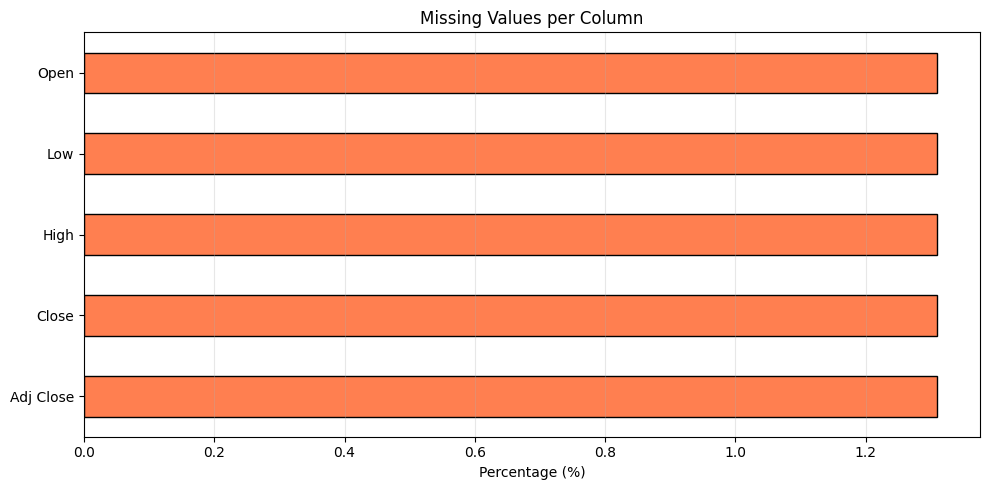


Close NaN: 39 tanggal
   Rentang: 2016-01-18 s/d 2023-11-23


In [2]:
# Missing value analysis
missing = df.isna().sum()
missing_pct = round(missing / len(df) * 100, 2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Percentage (%)', ascending=False)

print("MISSING VALUES SUMMARY")
print("="*50)
display(missing_df[missing_df['Missing Count'] > 0])

# Visualisasi
plt.figure(figsize=(10, 5))
missing_pct[missing_pct > 0].plot(kind='barh', color='coral', edgecolor='black')
plt.xlabel('Percentage (%)')
plt.title('Missing Values per Column')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Detail NaN dates untuk Close
if missing.get('Close', 0) > 0:
    nan_dates = df[df['Close'].isna()].index.tolist()
    print(f"\nClose NaN: {len(nan_dates)} tanggal")
    print(f"   Rentang: {min(nan_dates).date()} s/d {max(nan_dates).date()}")

### 2.2 Repaired Data Flag

In [3]:
# Repaired flag analysis
if 'Repaired?' in df.columns:
    repaired_count = df['Repaired?'].sum()
    repaired_pct = round(repaired_count / len(df) * 100, 2)
    
    print("REPAIRED DATA SUMMARY")
    print("="*50)
    print(f"Total data yang di-repair: {repaired_count} ({repaired_pct}%)")
    
    if repaired_count > 0:
        print("\nTanggal yang di-repair:")
        repaired_dates = df[df['Repaired?'] == True].index.tolist()
        for d in repaired_dates:
            print(f"   • {d.date()}")
else:
    print("Kolom 'Repaired?' tidak tersedia")

REPAIRED DATA SUMMARY
Total data yang di-repair: 4 (0.13%)

Tanggal yang di-repair:
   • 2024-11-15
   • 2025-05-26
   • 2025-06-19
   • 2025-07-04


### 2.3 Settlement-Style Data

SETTLEMENT-STYLE DATA (FLAT CANDLE)
Flat candle: 2477 hari (83.15%)
   Normal candle: 502 hari (16.85%)

Flat Candle per Tahun:
   2014: 64.1% ████████████
   2015: 73.4% ██████████████
   2016: 36.5% ███████
   2017: 93.2% ██████████████████
   2018: 99.6% ███████████████████
   2019: 96.0% ███████████████████
   2020: 97.2% ███████████████████
   2021: 97.2% ███████████████████
   2022: 97.2% ███████████████████
   2023: 80.9% ████████████████
   2024: 79.8% ███████████████
   2025: 79.5% ███████████████
   2026: 63.4% ████████████


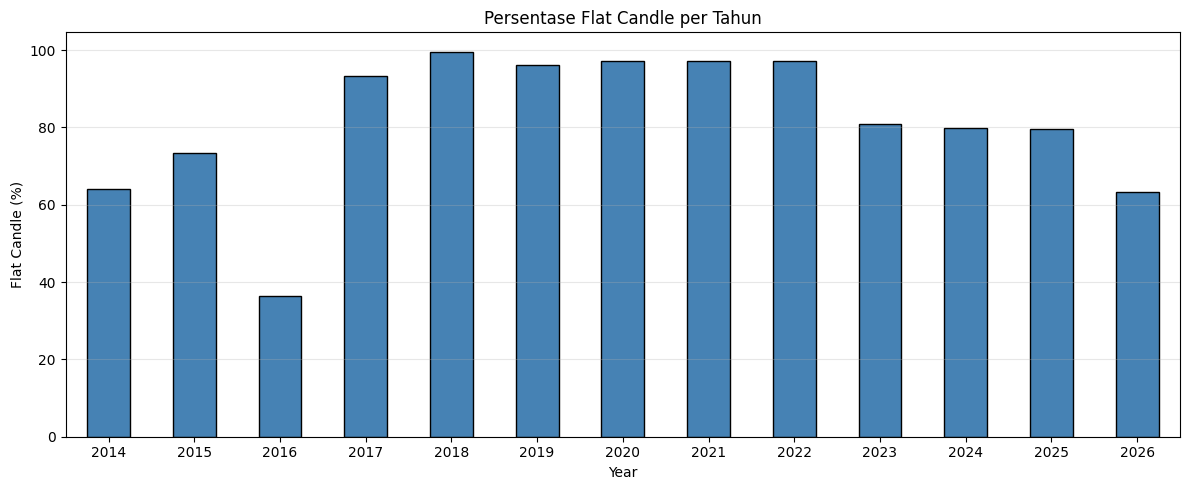


IMPLIKASI:
   • Data ini adalah settlement-style (1 harga/hari)
   • Open/High/Low = Close (disalin, bukan trading intraday)
   • Tidak cocok untuk analisis candlestick
   • Masih OK untuk forecasting return/price


In [4]:
# Deteksi flat candle (O=H=L=C)
flat_mask = (df['Open'] == df['High']) & (df['High'] == df['Low']) & (df['Low'] == df['Close'])
flat_count = flat_mask.sum()
flat_pct = round(flat_count / len(df) * 100, 2)

print("SETTLEMENT-STYLE DATA (FLAT CANDLE)")
print("="*50)
print(f"Flat candle: {flat_count} hari ({flat_pct}%)")
print(f"   Normal candle: {len(df) - flat_count} hari ({100-flat_pct:.2f}%)")

# Per tahun
df_temp = df.copy()
df_temp['Year'] = df_temp.index.year
df_temp['Is_Flat'] = flat_mask
flat_by_year = df_temp.groupby('Year')['Is_Flat'].mean() * 100

print("\nFlat Candle per Tahun:")
for year, pct in flat_by_year.items():
    bar = '█' * int(pct/5)
    print(f"   {year}: {pct:.1f}% {bar}")

# Visualisasi
plt.figure(figsize=(12, 5))
flat_by_year.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Flat Candle (%)')
plt.title('Persentase Flat Candle per Tahun')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nIMPLIKASI:")
print("   • Data ini adalah settlement-style (1 harga/hari)")
print("   • Open/High/Low = Close (disalin, bukan trading intraday)")
print("   • Tidak cocok untuk analisis candlestick")
print("   • Masih OK untuk forecasting return/price")

### 2.4 Stale / Plateau Behavior

In [5]:
# Deteksi streak harga konstan
df_temp = df.copy()
df_temp['Price_Changed'] = (df_temp['Close'] != df_temp['Close'].shift(1)).astype(int)
df_temp['Streak_Group'] = (df_temp['Price_Changed'] != df_temp['Price_Changed'].shift(1)).cumsum()
df_temp['Streak_Length'] = df_temp.groupby('Streak_Group').cumcount() + 1

# Cari streak ≥5 hari
long_streaks = df_temp[df_temp['Price_Changed'] == 0].groupby('Streak_Group').size()
runs_ge_5 = (long_streaks >= 5).sum()
max_streak = long_streaks.max() if len(long_streaks) > 0 else 0

# Return = 0
df_temp['Return'] = df_temp['Close'].pct_change(fill_method=None)
zero_return = (df_temp['Return'] == 0).sum()
zero_return_pct = round(zero_return / len(df) * 100, 2)

print("STALE / PLATEAU BEHAVIOR")
print("="*50)
print(f"Run dengan ≥5 hari konstan: {runs_ge_5} run")
print(f"Streak terpanjang: ~{max_streak} hari")
print(f"Hari dengan return = 0: {zero_return} ({zero_return_pct}%)")

# Tampilkan streak terpanjang
if max_streak >= 5:
    longest_streak_group = long_streaks[long_streaks == max_streak].index[0]
    streak_data = df_temp[df_temp['Streak_Group'] == longest_streak_group]
    print(f"\nStreak terpanjang:")
    print(f"   Dari: {streak_data.index.min().date()}")
    print(f"   Sampai: {streak_data.index.max().date()}")
    print(f"   Harga: {streak_data['Close'].iloc[0]}")

STALE / PLATEAU BEHAVIOR
Run dengan ≥5 hari konstan: 17 run
Streak terpanjang: ~89 hari
Hari dengan return = 0: 480 (16.11%)

Streak terpanjang:
   Dari: 2019-02-20
   Sampai: 2019-06-26
   Harga: 2225.0


#### Tabel Lengkap 17 Run Streak (≥5 Hari Konstan)

In [ ]:
# Fungsi untuk ekstrak semua streak ≥5 hari
def extract_streaks(df, min_streak=5):
    """Extract semua streak periode dengan harga konstan"""
    df_temp = df.copy()
    df_temp['Price_Changed'] = (df_temp['Close'] != df_temp['Close'].shift(1)).astype(int)
    df_temp['Streak_Group'] = (df_temp['Price_Changed'] != df_temp['Price_Changed'].shift(1)).cumsum()
    
    # Group streak
    streak_groups = df_temp[df_temp['Price_Changed'] == 0].groupby('Streak_Group')
    streak_lengths = streak_groups.size()
    
    # Filter streak ≥ min_streak
    long_streaks = streak_lengths[streak_lengths >= min_streak]
    
    # Ekstrak detail setiap streak
    streak_details = []
    for i, (group_id, length) in enumerate(long_streaks.items(), 1):
        group_data = df_temp[df_temp['Streak_Group'] == group_id]
        start_date = group_data.index.min()
        end_date = group_data.index.max()
        price = group_data['Close'].iloc[0]
        
        # Kategorikan
        if length >= 30:
            kategori = "Streak sangat panjang"
        elif length >= 10:
            kategori = "Streak panjang"
        else:
            kategori = "Streak pendek"
        
        # Cek jika ini missing data
        if pd.isna(price):
            kategori = "Missing data block"
        
        streak_details.append({
            '#': i,
            'Start Date': start_date,
            'End Date': end_date,
            'Durasi (Hari)': length,
            'Harga Close': price,
            'Keterangan': kategori
        })
    
    return pd.DataFrame(streak_details)

# Ekstrak dan tampilkan tabel
streak_table = extract_streaks(df, min_streak=5)

# Tampilkan dengan styling
print("="*100)
print("TABEL LENGKAP 17 RUN STREAK (≥5 Hari Konstan)")
print("="*100)
print(f"\nTotal run: {len(streak_table)} periode")
print(f"Total hari dalam streak: {streak_table['Durasi (Hari)'].sum()} hari ({streak_table['Durasi (Hari)'].sum()/len(df)*100:.2f}% dari data)")
print(f"\nStreak terpanjang: {streak_table['Durasi (Hari)'].max()} hari")
print(f"Rata-rata durasi: {streak_table['Durasi (Hari)'].mean():.1f} hari\n")
print("-"*100)

# Display tabel
display(streak_table.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
}).format({
    'Start Date': lambda x: x.strftime('%Y-%m-%d') if pd.notna(x) else 'NaT',
    'End Date': lambda x: x.strftime('%Y-%m-%d') if pd.notna(x) else 'NaT',
    'Harga Close': lambda x: f"{x:,.2f}" if pd.notna(x) else 'NaN'
}).background_gradient(subset=['Durasi (Hari)'], cmap='YlOrRd'))

# Highlight streak terpanjang
max_streak_idx = streak_table['Durasi (Hari)'].idxmax()
print(f"\nSTREAK TERPANJANG: {streak_table.loc[max_streak_idx, 'Start Date'].strftime('%Y-%m-%d')} s/d {streak_table.loc[max_streak_idx, 'End Date'].strftime('%Y-%m-%d')}")
print(f"   Durasi: {streak_table.loc[max_streak_idx, 'Durasi (Hari)']} hari dengan harga {streak_table.loc[max_streak_idx, 'Harga Close']}")

TABEL LENGKAP 17 RUN STREAK (≥5 Hari Konstan)

Total run: 17 periode
Total hari dalam streak: 416 hari (13.96% dari data)

Streak terpanjang: 89 hari
Rata-rata durasi: 24.5 hari

----------------------------------------------------------------------------------------------------


,#,Start Date,End Date,Durasi (Hari),Harga Close,Keterangan
0,1,2017-10-10,2017-10-16,5,"2,236.25",Streak pendek
1,2,2017-10-20,2017-10-27,6,"2,225.00",Streak pendek
2,3,2017-10-31,2017-11-28,20,"2,231.50",Streak panjang
3,4,2017-11-30,2017-12-27,19,"2,239.50",Streak panjang
4,5,2017-12-29,2018-01-26,19,"2,244.50",Streak panjang
5,6,2018-01-31,2018-02-26,18,"2,250.00",Streak panjang
6,7,2018-02-28,2018-03-27,20,"2,255.00",Streak panjang
7,8,2018-04-03,2018-05-29,40,"2,300.00",Streak sangat panjang
8,9,2018-05-31,2018-06-27,20,"2,305.00",Streak panjang
9,10,2018-06-29,2018-07-27,20,"2,309.25",Streak panjang



⚠️ STREAK TERPANJANG: 2019-02-20 s/d 2019-06-26
   Durasi: 89 hari dengan harga 2225.0


### 2.5 Outlier Detection

OUTLIER DETECTION (Return)
Statistik Return:
   Mean:   0.0002 (0.02%)
   Std:    0.0123 (1.23%)
   Min:    -0.1820 (-18.20%)
   Max:    0.0691 (6.91%)

Outlier (IQR method):
   Total: 150 (5.04%)
   Bound: [-0.0237, 0.0239]

Top 5 Return Ekstrem:


,Close,Return
Date,,
2019-06-27,1820.0,-0.182022
2022-03-08,3485.5,-0.069417
2022-03-09,3286.5,-0.057094
2021-10-21,2935.5,-0.055730
2021-10-27,2716.5,-0.052329


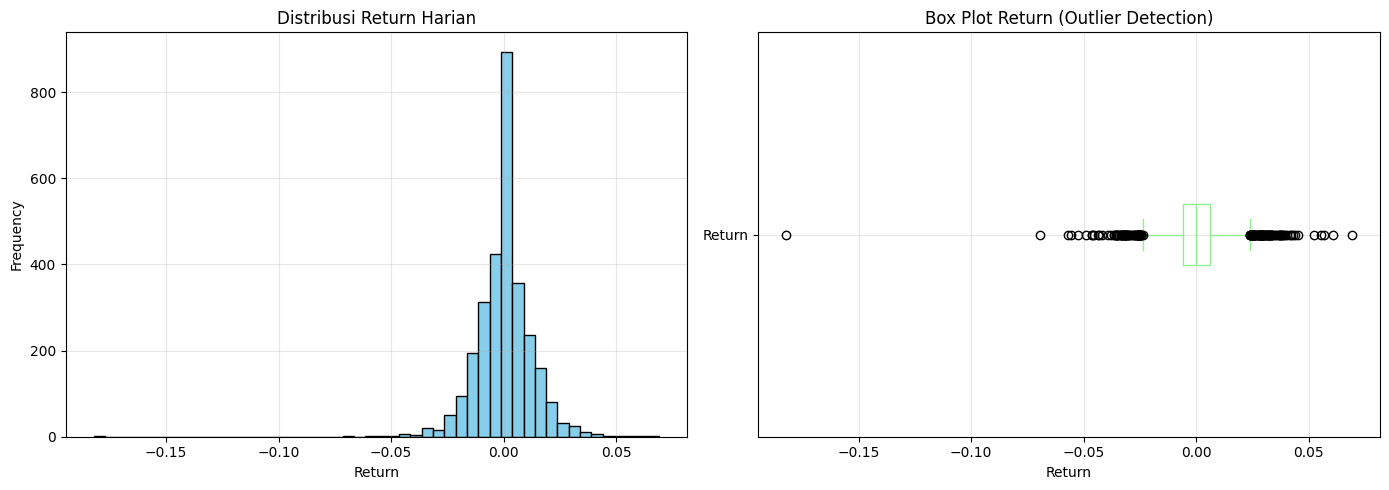


OUTLIER TERBESAR:
   Tanggal: 2019-06-27
   Return: -0.1820 (-18.20%)
   → Diduga artefak data (stale update)


In [7]:
# Hitung return
df_temp = df.copy()
df_temp['Return'] = df_temp['Close'].pct_change(fill_method=None)

# Outlier dengan IQR
Q1 = df_temp['Return'].quantile(0.25)
Q3 = df_temp['Return'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_temp[(df_temp['Return'] < lower_bound) | (df_temp['Return'] > upper_bound)]
outlier_pct = round(len(outliers) / len(df) * 100, 2)

print("OUTLIER DETECTION (Return)")
print("="*50)
print(f"Statistik Return:")
print(f"   Mean:   {df_temp['Return'].mean():.4f} ({df_temp['Return'].mean()*100:.2f}%)")
print(f"   Std:    {df_temp['Return'].std():.4f} ({df_temp['Return'].std()*100:.2f}%)")
print(f"   Min:    {df_temp['Return'].min():.4f} ({df_temp['Return'].min()*100:.2f}%)")
print(f"   Max:    {df_temp['Return'].max():.4f} ({df_temp['Return'].max()*100:.2f}%)")
print(f"\nOutlier (IQR method):")
print(f"   Total: {len(outliers)} ({outlier_pct}%)")
print(f"   Bound: [{lower_bound:.4f}, {upper_bound:.4f}]")

# Top 5 outliers
print("\nTop 5 Return Ekstrem:")
top_outliers = df_temp.nsmallest(5, 'Return')[['Close', 'Return']]
display(top_outliers)

# Visualisasi
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df_temp['Return'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Return')
plt.title('Distribusi Return Harian')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
df_temp['Return'].plot(kind='box', vert=False, color='lightgreen')
plt.xlabel('Return')
plt.title('Box Plot Return (Outlier Detection)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Highlight outlier terbesar
max_outlier_date = df_temp['Return'].idxmin()
max_outlier_val = df_temp.loc[max_outlier_date, 'Return']
print(f"\nOUTLIER TERBESAR:")
print(f"   Tanggal: {max_outlier_date.date()}")
print(f"   Return: {max_outlier_val:.4f} ({max_outlier_val*100:.2f}%)")
print(f"   → Diduga artefak data (stale update)" if max_outlier_val < -0.1 else "   → Pergerakan normal")

### 2.6 Data Quality Summary

In [8]:
# Summary box
print("\n" + "="*60)
print("DATA QUALITY SUMMARY")
print("="*60)

issues = []

# Missing values
if missing.get('Close', 0) > 0:
    issues.append(f"Missing Close: {missing['Close']} ({missing_pct.get('Close', 0):.2f}%)")
else:
    issues.append("No missing values")

# Repaired
if 'Repaired?' in df.columns:
    if repaired_count > 0:
        issues.append(f"Repaired data: {repaired_count} ({repaired_pct}%)")
    else:
        issues.append("No repaired data")

# Flat candle
if flat_pct > 50:
    issues.append(f"High flat candle: {flat_pct}% (settlement-style)")
else:
    issues.append("Normal candle pattern")

# Stale
if zero_return_pct > 10:
    issues.append(f"Stale behavior: {zero_return_pct}% zero return")
else:
    issues.append("Low stale behavior")

# Outliers
if outlier_pct > 5:
    issues.append(f"High outliers: {outlier_pct}%")
else:
    issues.append("Acceptable outliers")

for issue in issues:
    print(issue)

print("\n" + "="*60)
print("REKOMENDASI UNTUK ML:")
print("="*60)
print("1. Drop Close NaN (jika ada)")
print("2. Drop/winsorize outlier ekstrem (2019-06-27)")
print("3. Fokus pada fitur Close/return (abaikan OHLC untuk candlestick)")
print("4. Buat flag is_stale untuk feature engineering")
print("5. Gunakan time-series cross validation")
print("="*60)


DATA QUALITY SUMMARY
Missing Close: 39 (1.31%)
Repaired data: 4 (0.13%)
High flat candle: 83.15% (settlement-style)
Stale behavior: 16.11% zero return
High outliers: 5.04%

REKOMENDASI UNTUK ML:
1. Drop Close NaN (jika ada)
2. Drop/winsorize outlier ekstrem (2019-06-27)
3. Fokus pada fitur Close/return (abaikan OHLC untuk candlestick)
4. Buat flag is_stale untuk feature engineering
5. Gunakan time-series cross validation


## 3️. Univariate Analysis

DESCRIPTIVE STATISTICS


,Open,High,Low,Close,Volume
count,2940.000000,2940.000000,2940.000000,2940.000000,2979.000000
mean,2212.418282,2213.467602,2211.440646,2212.508759,8.049681
std,389.811568,389.946280,389.988763,390.048946,47.636103
min,1456.000000,1456.000000,1452.000000,1452.000000,0.000000
25%,1911.625000,1915.375000,1911.625000,1915.375000,0.000000
50%,2237.125000,2237.500000,2236.250000,2236.250000,0.000000
75%,2425.125000,2426.625000,2424.500000,2426.312500,6.000000
max,3873.000000,3873.000000,3873.000000,3873.000000,2210.000000


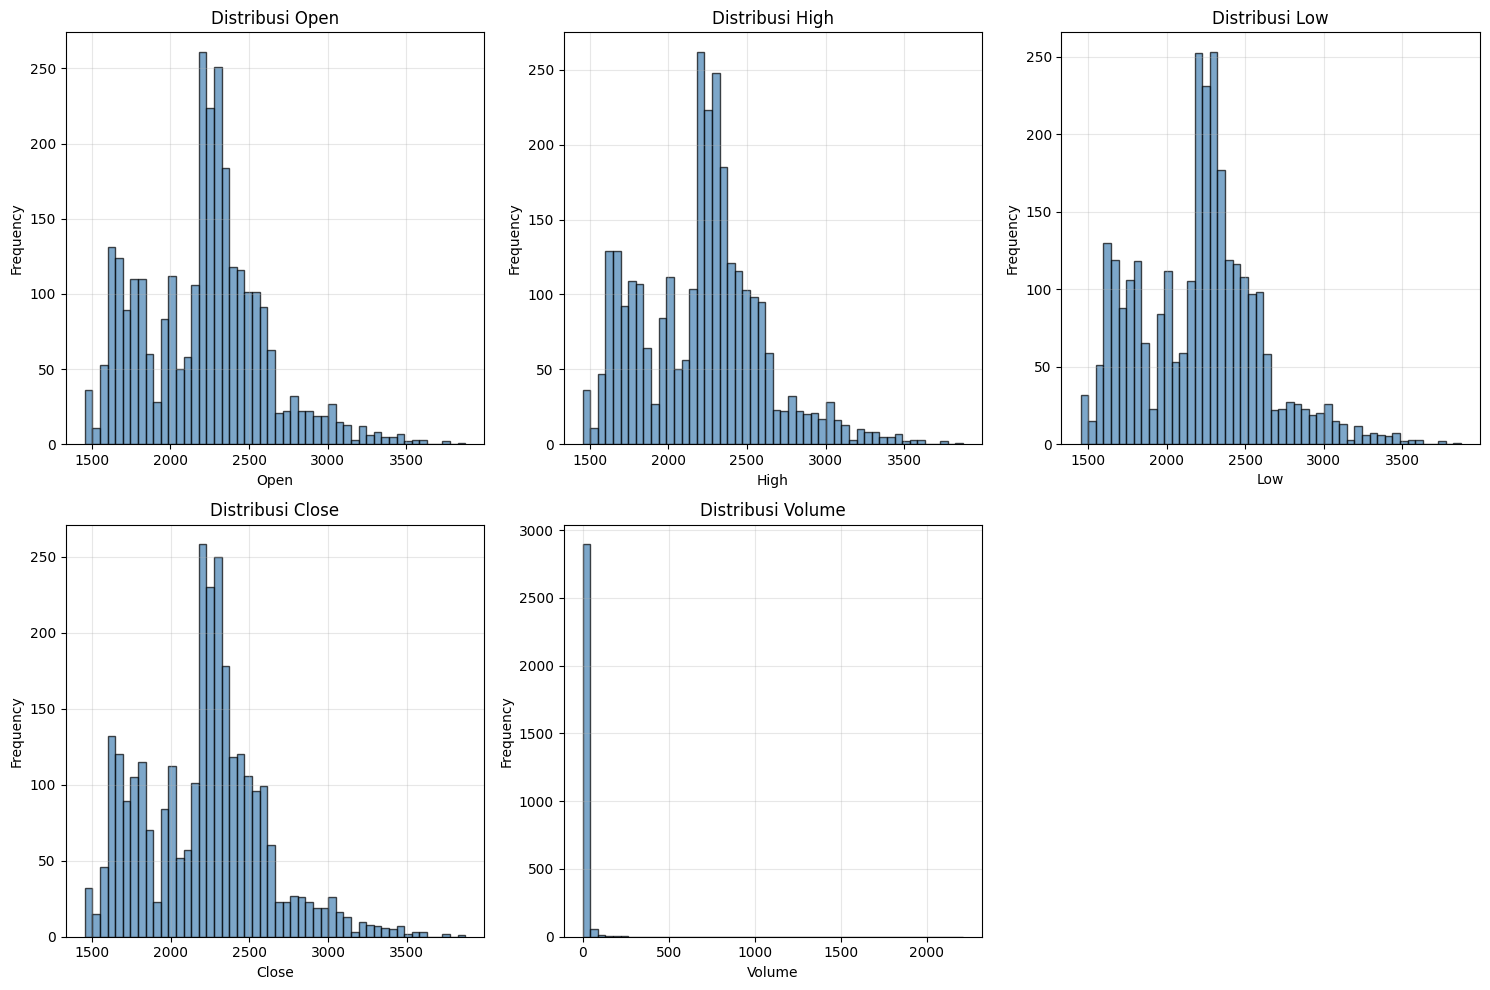

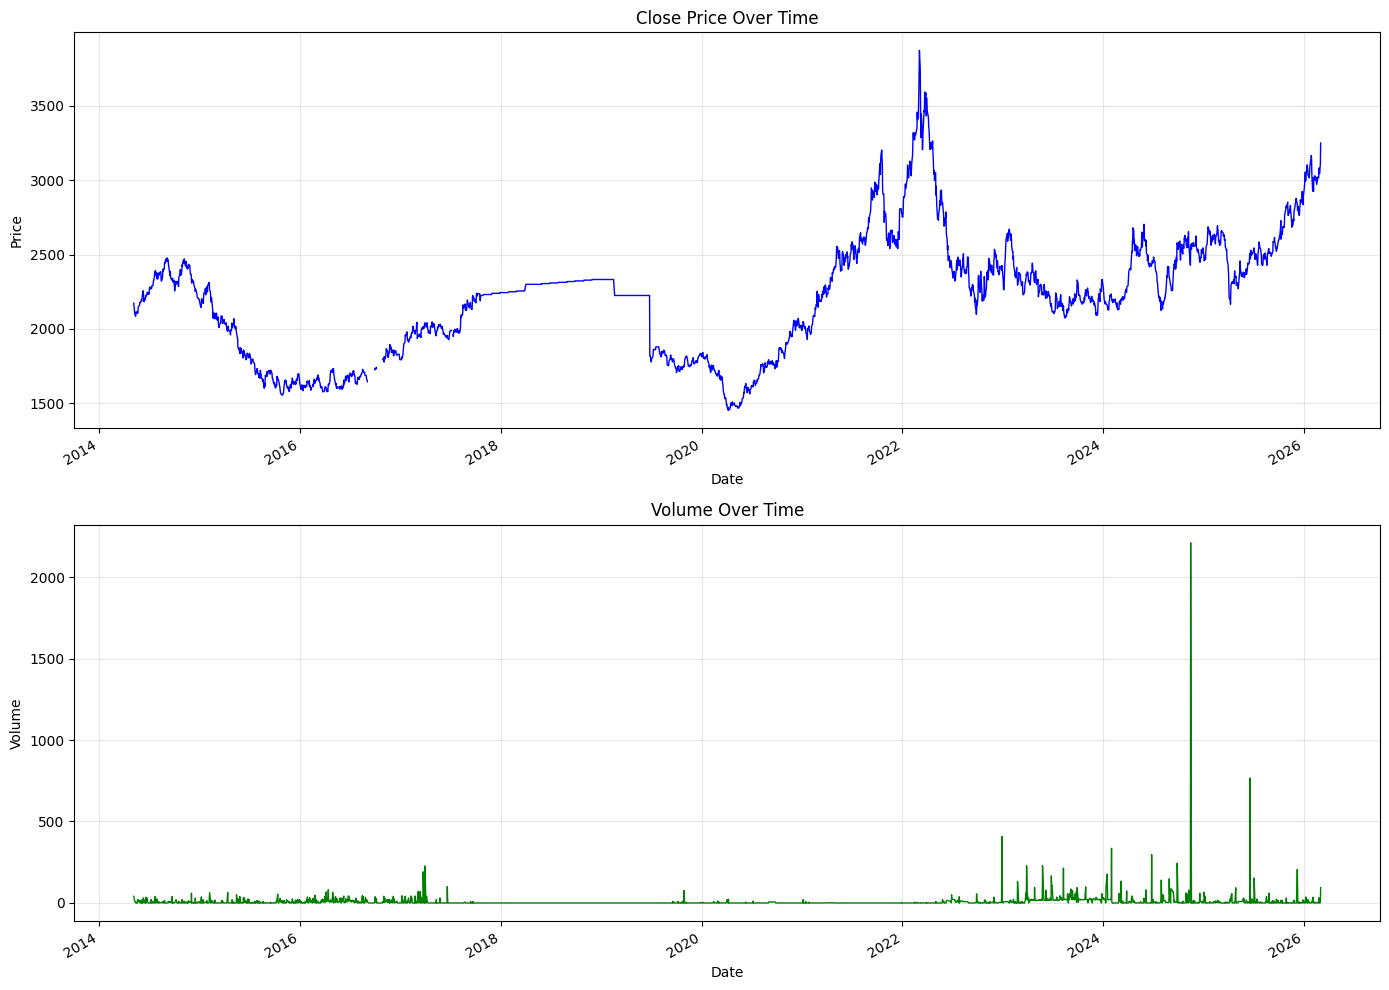

In [9]:
# Statistik deskriptif
print("DESCRIPTIVE STATISTICS")
print("="*60)
display(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

# Visualisasi distribusi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for idx, col in enumerate(cols):
    ax = axes[idx // 3, idx % 3]
    df[col].plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(col)
    ax.set_title(f'Distribusi {col}')
    ax.grid(alpha=0.3)

# Kosongkan subplot terakhir
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Time series plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Close price
df['Close'].plot(ax=axes[0], color='blue', linewidth=1)
axes[0].set_ylabel('Price')
axes[0].set_title('Close Price Over Time')
axes[0].grid(alpha=0.3)

# Volume
df['Volume'].plot(ax=axes[1], color='green', linewidth=1)
axes[1].set_ylabel('Volume')
axes[1].set_title('Volume Over Time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4️. Bivariate & Multivariate Analysis

CORRELATION MATRIX


,Open,High,Low,Close,Volume
Open,1.00,1.000,1.000,1.00,0.010
High,1.00,1.000,1.000,1.00,0.011
Low,1.00,1.000,1.000,1.00,0.009
Close,1.00,1.000,1.000,1.00,0.010
Volume,0.01,0.011,0.009,0.01,1.000


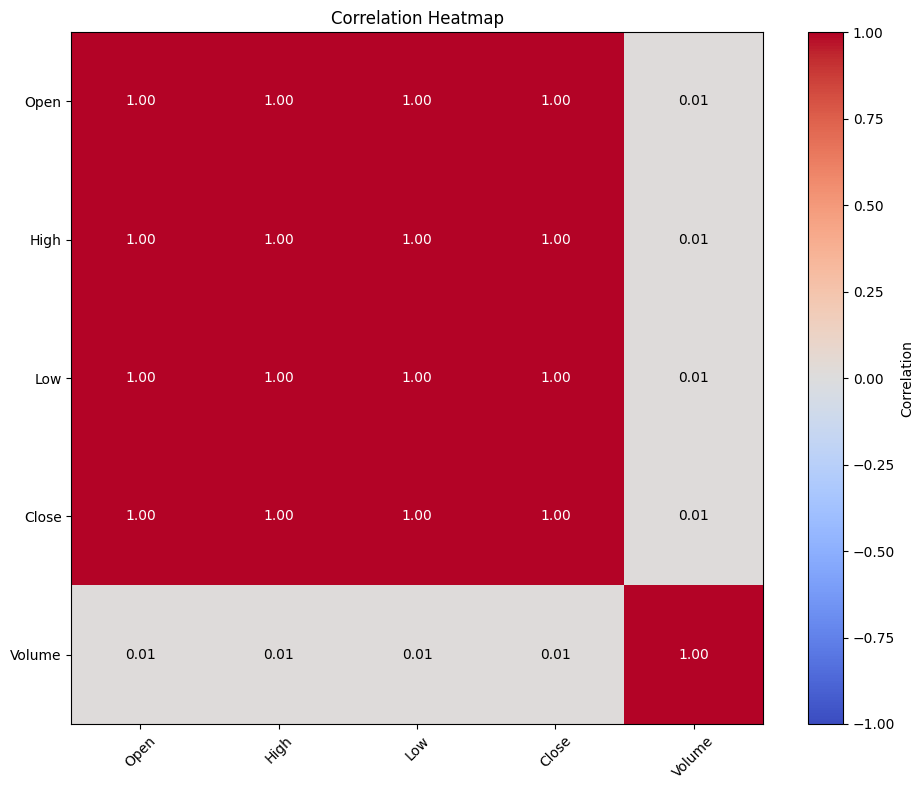


SCATTER PLOT MATRIX (sample 500 data)


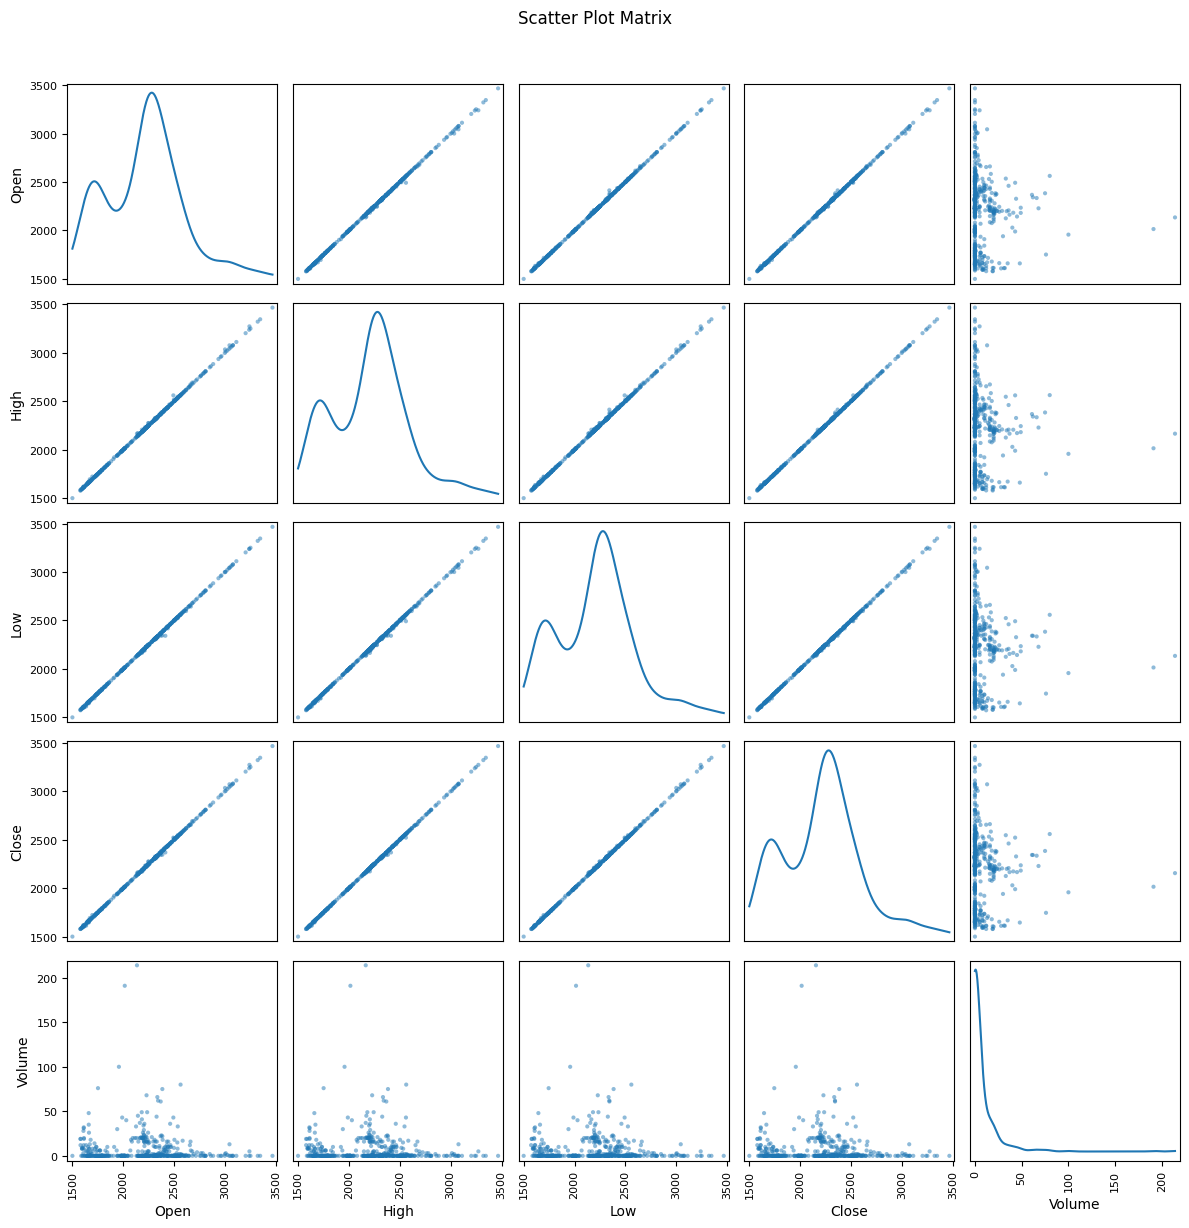

In [10]:
# Correlation matrix
print("CORRELATION MATRIX")
print("="*60)
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
corr_matrix = df[corr_cols].corr()
display(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Heatmap')

# Anotasi nilai
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', 
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

# Scatter plot matrix (sample untuk performa)
print("\nSCATTER PLOT MATRIX (sample 500 data)")
df_sample = df.sample(500, random_state=42)
pd.plotting.scatter_matrix(df_sample[corr_cols], figsize=(12, 12), alpha=0.5, diagonal='kde')
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.tight_layout()
plt.show()

PRICE vs VOLUME


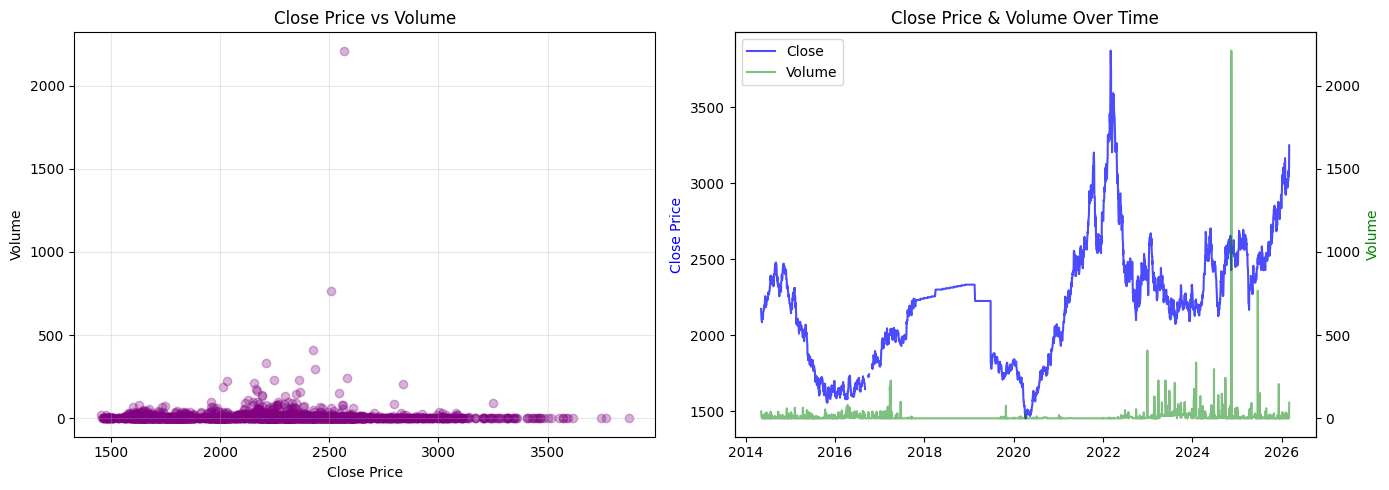

In [11]:
# Price vs Volume relationship
print("PRICE vs VOLUME")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['Close'], df['Volume'], alpha=0.3, color='purple')
axes[0].set_xlabel('Close Price')
axes[0].set_ylabel('Volume')
axes[0].set_title('Close Price vs Volume')
axes[0].grid(alpha=0.3)

# Time series dengan dual axis
ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(df.index, df['Close'], color='blue', label='Close', alpha=0.7)
ax2.plot(df.index, df['Volume'], color='green', label='Volume', alpha=0.5)

ax1.set_ylabel('Close Price', color='blue')
ax2.set_ylabel('Volume', color='green')
ax1.set_title('Close Price & Volume Over Time')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()